# Exam (Base Notebook)

**Instructions**

- Work independently. No AI or other help was used. 
- Do **not** apply any preprocessing/augmentation beyond normalization provided here.
- Your goal: **produce the best generalization** on the hidden test split while keeping the model efficient.
- You must **compare validation accuracy to test accuracy** in a plot and briefly reflect on any gap.
- You may modify only the sections marked **Your work**. Do not change fixed cells.


## 0. Honor Statement
I, `Jakub Marciszonek`, assure that I have completed this exam independently and followed all rules.

In [1]:
# 1) Imports & Reproducibility (Fixed)
import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


In [2]:
# 2) Load Data (Fixed)
# Expects a pickle file 'mnist.hupsista' containing (X, y) as numpy arrays.
with open('mnist.hupsista','rb') as f:
    X_all, y_all = pickle.load(f)

X_all = X_all.astype('float32')
# Normalize to [0,1]
if X_all.max() > 1.0:
    X_all /= 255.0
# Ensure channel dimension
if X_all.ndim == 3:
    X_all = X_all[..., None]

unique_labels = np.unique(y_all)


In [3]:
# 3) Create Train/Val/Test Splits (Fixed)
# Hold-out test once; then split train/val from the remainder.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


Train: (6400, 28, 28, 1) Val: (1600, 28, 28, 1) Test: (2000, 28, 28, 1)


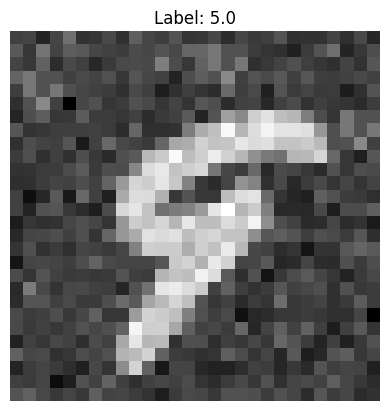

In [4]:
# 4) Quick Visual Check (Fixed)
idx = np.random.randint(0, len(X_train))
plt.imshow(X_train[idx].squeeze(), cmap='gray')
plt.title(f'Label: {y_train[idx]}')
plt.axis('off');plt.show()


## 1. Baseline model222
Check this CNN baseline. Leave as it is. Start fixing it in the next stage.

In [5]:
from tensorflow.keras import layers, models

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(10, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=2, validation_data=(X_val, y_val), verbose=0)
print()

## 2. Learning Curves (Fixed utility)
Plot training vs validation curves to diagnose generalization.

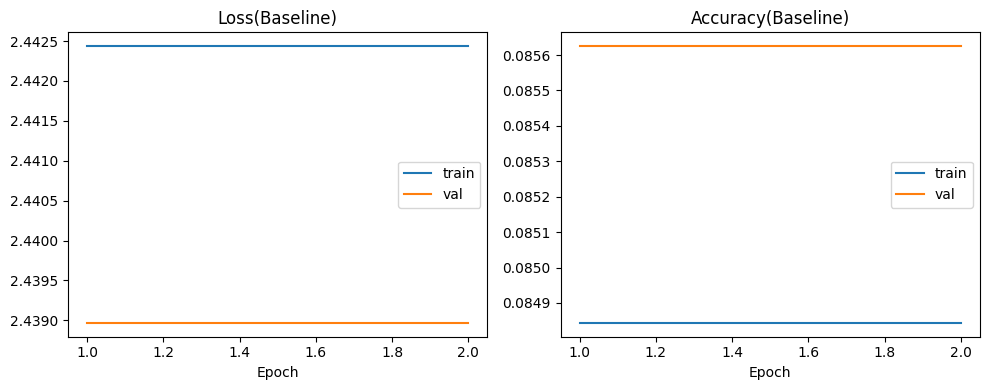

In [6]:
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')


## 3. Validation vs Test Accuracy (Required)
Evaluate on the held-out test set and overlay the test accuracy on the validation curve. Then write a short reflection (3–5 sentences) on the generalization gap.

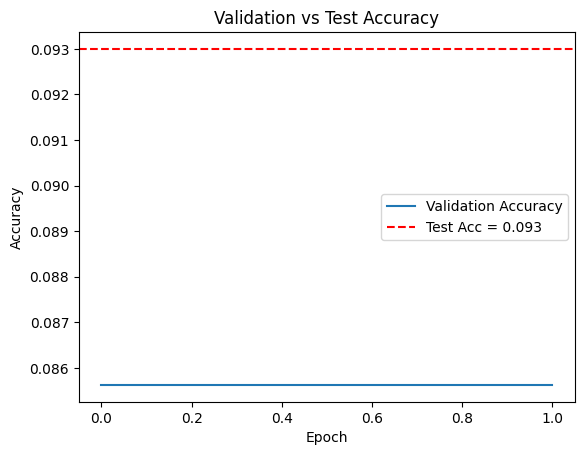

Final Test Accuracy: 0.0930


In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')


### Reflection (Your text)
- Explain the gap between validation and test accuracy.
- What might cause it, and what would you try next to reduce it?
- How much of the dataset do you use for training, validation, and testing? Explain your answer with the % calculation.
- How many images are there in the original dataset?
- How big are the images?
- What observations can you tell about the original data?  
- What are possible labels for the images?
- What are the steps when making models?
- <b>Make sure you explain every step well!<b>
- <b>Make sure your model is as optimized as possible!<b>

The gap is caused by overfitting of the model to the trained data.

The said overfitting is probably the cause, reducing epochos and increasing efficiency of the training would reduce the gap.

20% of dataset is used for testing and 20% out of remaining 80% (16% of total) is used for validation the rest 64% is used for training.

In the dataset there is 10000 images

The images are 28x28

that the data are consited out of images of handwritten numbers they are blury and not perfect

possibly there are 10 labels according to every number from 0-9

First use simple model to path the trends 
flatten the image to vectors
compile model set learning rate and optimizer 
then run the training few epoch and follow the trend

knowing the trends implement changes as changing learining rate number of epoch and change the layers to meet consistent outcome

in images case downgrading images using Conv2D is going to probably increase the efficiency

## 4. Improved Model (Your work)
Build a better model, train it here as many times as you feel like and when you are pleased with it, title it `final_model`.  Report every try individually, not only the final version.

Explain every step with markdown text and code comments.   

Unrunnable code is not checked. 

### Optimazation vs. Accuracy Check

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - accuracy: 0.2811 - loss: 2.1630 - val_accuracy: 0.3900 - val_loss: 2.0226
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - accuracy: 0.4298 - loss: 1.8498 - val_accuracy: 0.3994 - val_loss: 1.9914
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step - accuracy: 0.4747 - loss: 1.7254 - val_accuracy: 0.4025 - val_loss: 1.9972
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - accuracy: 0.4983 - loss: 1.6479 - val_accuracy: 0.4050 - val_loss: 2.0124
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - accuracy: 0.5200 - loss: 1.5938 - val_accuracy: 0.4038 - val_loss: 2.0311
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - accuracy: 0.5333 - loss: 1.5532 - val_accuracy: 0.4031 - val_loss: 2.0513
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - accuracy: 0.5409 - loss: 1.5211 - val_accuracy: 0.4044 - val_loss: 2.0722
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - accuracy: 0.5484 - loss: 1.4946 - 

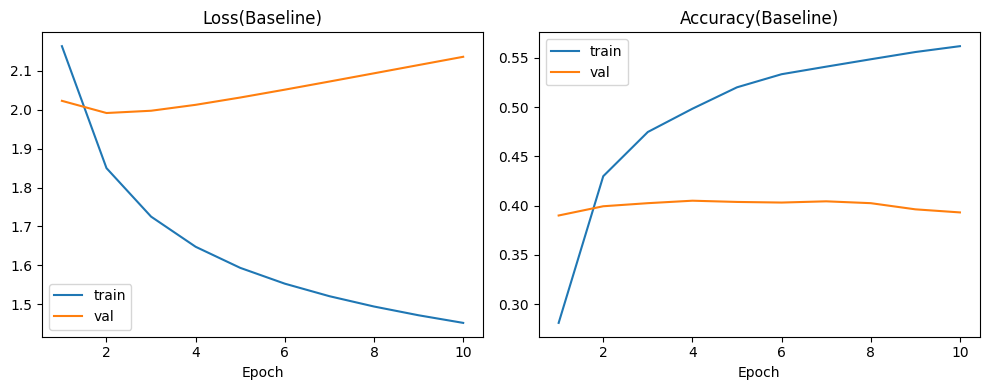

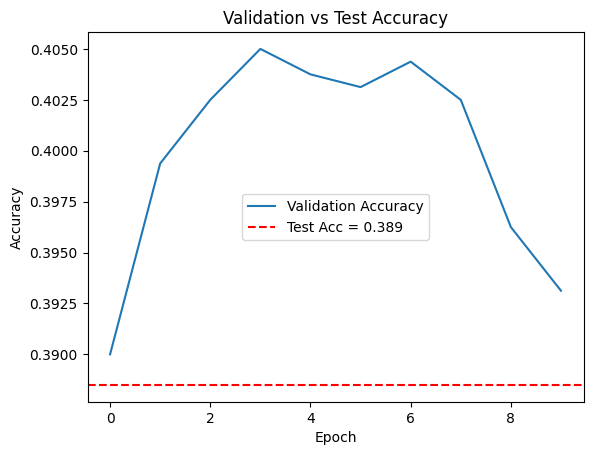

Final Test Accuracy: 0.3885


In [8]:
from tensorflow.keras import layers, models

model1 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(10, activation='sigmoid')
])

model1.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.05),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model1.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), verbose=1)
print()

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')


test_loss, test_acc = model1.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')


I have increased learning rate and number of epochs which in resolt from final accuracy of ~0.1 the algorythm is doing now ~0.4. The graph doesn't look consistent so I'm pushing the changes more

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3706 - loss: 1.9855 - val_accuracy: 0.4212 - val_loss: 1.9303
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4716 - loss: 1.7266 - val_accuracy: 0.4100 - val_loss: 2.0180
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5031 - loss: 1.6092 - val_accuracy: 0.3956 - val_loss: 2.1531
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5277 - loss: 1.5272 - val_accuracy: 0.3706 - val_loss: 2.3075
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5431 - loss: 1.4701 - val_accuracy: 0.3550 - val_loss: 2.4595
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5527 - loss: 1.4353 - val_accuracy: 0.3394 - val_loss: 2.6003
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5617 - loss: 1.4111 - val_accuracy: 0.3262 - val_loss: 2.7204
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5653 - loss: 1.3889 - val_accuracy: 0.

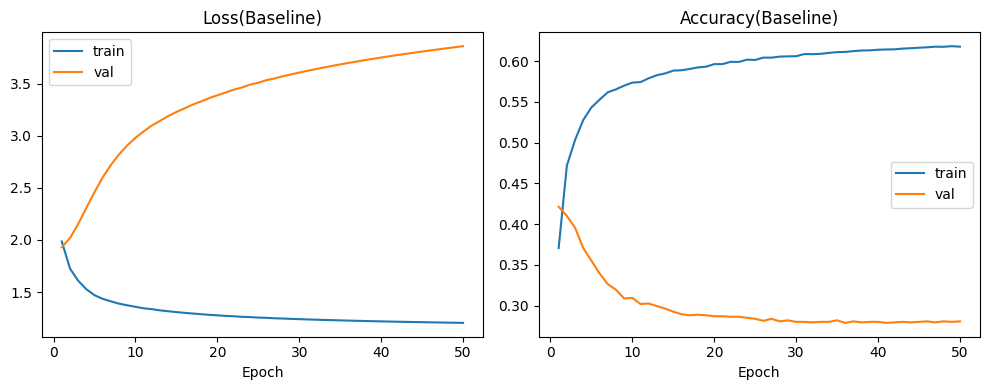

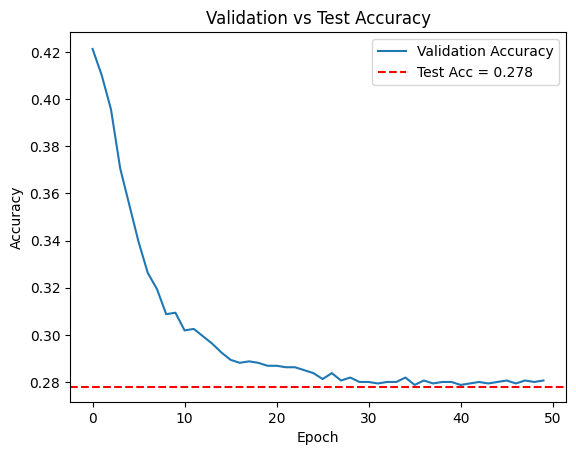

Final Test Accuracy: 0.2780


In [9]:
from tensorflow.keras import layers, models

model2 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(filters=16, kernel_size=2), # 14x14
    layers.Flatten(),
    layers.Dense(10, activation='sigmoid')
])

model2.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.05),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model2.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), verbose=1)
print()

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model2.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')


After using conv2d and dramaticaly increasing amount of epochs learning procces looks more organized and test accuracy is reduced to ~0.3 which is still not ideal but is consistent the gap between test and validation is dramatic so i should find a way to reduce epochs and optimaze the layers

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3711 - loss: 2.0020 - val_accuracy: 0.4206 - val_loss: 1.9364
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4628 - loss: 1.7629 - val_accuracy: 0.4194 - val_loss: 1.9903
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4925 - loss: 1.6564 - val_accuracy: 0.3975 - val_loss: 2.0952
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5191 - loss: 1.5741 - val_accuracy: 0.3869 - val_loss: 2.2202
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5333 - loss: 1.5093 - val_accuracy: 0.3725 - val_loss: 2.3548
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5469 - loss: 1.4612 - val_accuracy: 0.3575 - val_loss: 2.4887
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5556 - loss: 1.4283 - val_accuracy: 0.3425 - val_loss: 2.6164
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5605 - loss: 1.4037 - val_accuracy: 0.

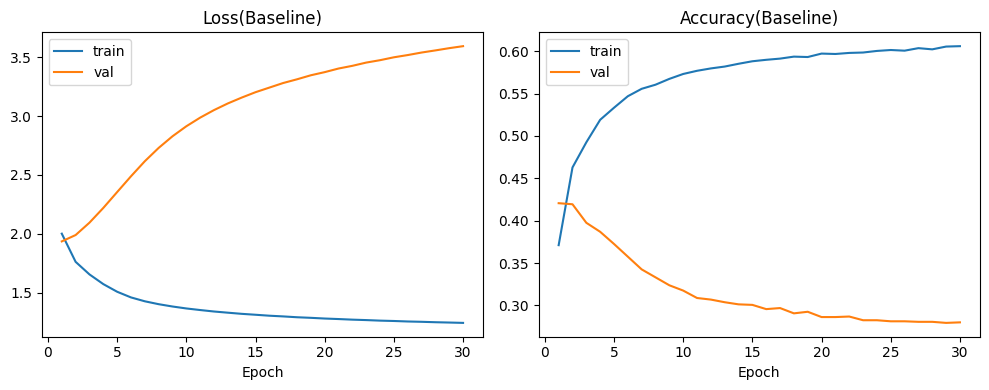

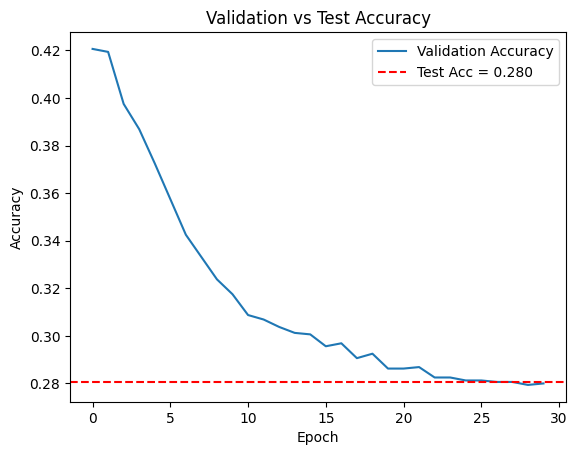

Final Test Accuracy: 0.2805


In [10]:
from tensorflow.keras import layers, models

model3 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    # hidden layer suppoused to be here but i can't rememmber the syntax and i got error everytime
    tf.keras.layers.Conv2D(filters=4, kernel_size=2), # 14x14
    # hidden layer suppoused to be here but i can't rememmber the syntax and i got error everytime
    layers.Flatten(),
    layers.Dense(10, activation='sigmoid')
])

model3.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.05),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model3.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val), verbose=1)
print()

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model3.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')


As expected reducing amount of filters in Conv2D and reducing epoch have not improved model output, but output is very simullar which means i should not use so many epochs in a first place.

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2011 - loss: 2.2047 - val_accuracy: 0.2969 - val_loss: 2.0085
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3913 - loss: 1.9059 - val_accuracy: 0.3931 - val_loss: 1.8847
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4478 - loss: 1.7842 - val_accuracy: 0.4250 - val_loss: 1.8253
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4686 - loss: 1.7009 - val_accuracy: 0.4500 - val_loss: 1.7683
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4870 - loss: 1.6288 - val_accuracy: 0.4737 - val_loss: 1.7061
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5003 - loss: 1.5626 - val_accuracy: 0.4831 - val_loss: 1.6708
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5142 - loss: 1.4977 - val_accuracy: 0.4913 - val_loss: 1.6239
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5259 - loss: 1.4410 - val_accuracy: 0.

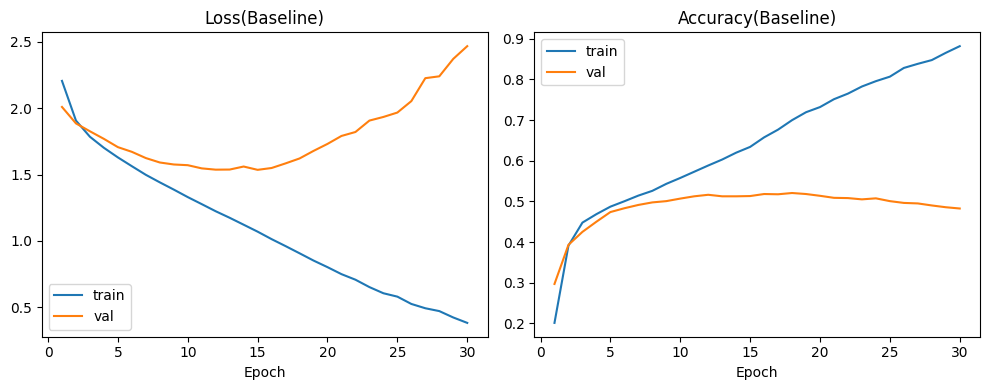

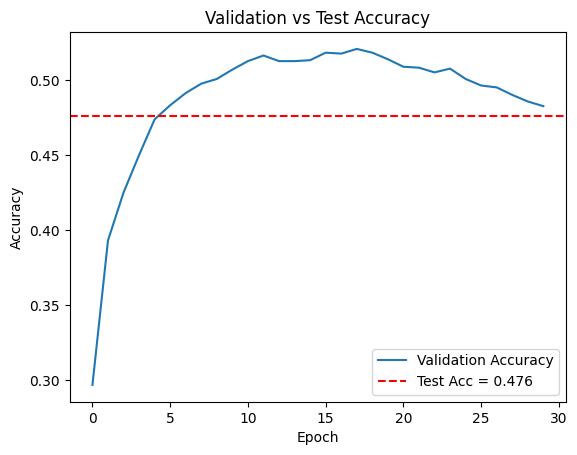

Final Test Accuracy: 0.4760


In [11]:
from tensorflow.keras import layers, models

model4 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    tf.keras.layers.Conv2D(16, 3, activation="relu"), # convelutional layer
    layers.MaxPool2D(),
    
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPool2D(),
    
    layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"), # dense layer
    layers.Dense(10, activation='sigmoid')
])

model4.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.05),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model4.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val), verbose=1)
print()

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model4.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')


By adding pooling and convelutional and dense layer model improved dramatically accuracy right now is around 50% and the gap between test and validation is closer then before

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2434 - loss: 2.1508 - val_accuracy: 0.3438 - val_loss: 1.9486
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4175 - loss: 1.8590 - val_accuracy: 0.4106 - val_loss: 1.8463
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4566 - loss: 1.7461 - val_accuracy: 0.4450 - val_loss: 1.7679
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4809 - loss: 1.6561 - val_accuracy: 0.4631 - val_loss: 1.7085
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5025 - loss: 1.5730 - val_accuracy: 0.4781 - val_loss: 1.6614
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5223 - loss: 1.4926 - val_accuracy: 0.4950 - val_loss: 1.6132
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5414 - loss: 1.4119 - val_accuracy: 0.5025 - val_loss: 1.5617
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5627 - loss: 1.3332 - val_accu

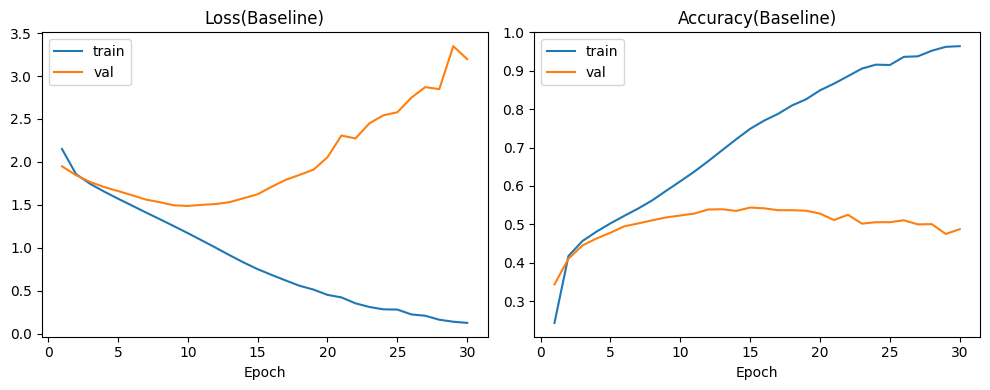

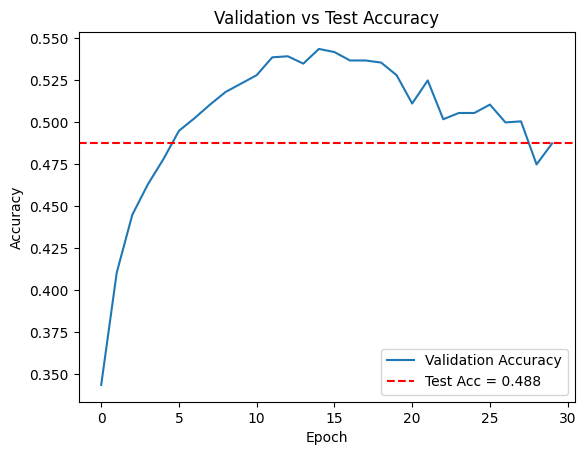

Final Test Accuracy: 0.4880


In [12]:
from tensorflow.keras import layers, models

model5 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    tf.keras.layers.Conv2D(64, 3, activation="relu"), # convelutional layer
    layers.MaxPool2D(),
    
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPool2D(),
    
    layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"), # dense layer
    layers.Dense(10, activation='sigmoid')
])

model5.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.05),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model5.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val), verbose=1)
print()

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model5.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')


The accuracy stayed very simular to previous model but the validation test gap seems to be closed

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1975 - loss: 2.2086 - val_accuracy: 0.3469 - val_loss: 2.0065
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3531 - loss: 1.9703 - val_accuracy: 0.4175 - val_loss: 1.8413
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4066 - loss: 1.8629 - val_accuracy: 0.4462 - val_loss: 1.7823
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4392 - loss: 1.7778 - val_accuracy: 0.4756 - val_loss: 1.7166
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4605 - loss: 1.7199 - val_accuracy: 0.4812 - val_loss: 1.6648
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4748 - loss: 1.6621 - val_accuracy: 0.4844 - val_loss: 1.6169
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4866 - loss: 1.6129 - val_accuracy: 0.4988 - val_loss: 1.5559
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4955 - loss: 1.5390 - val_accu

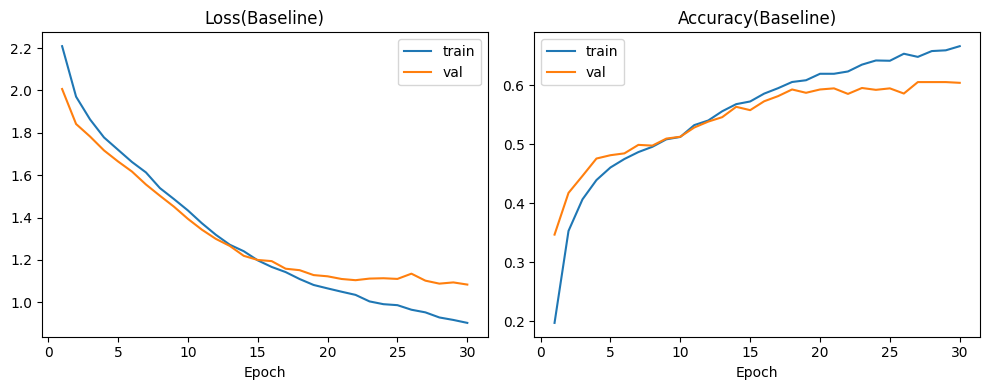

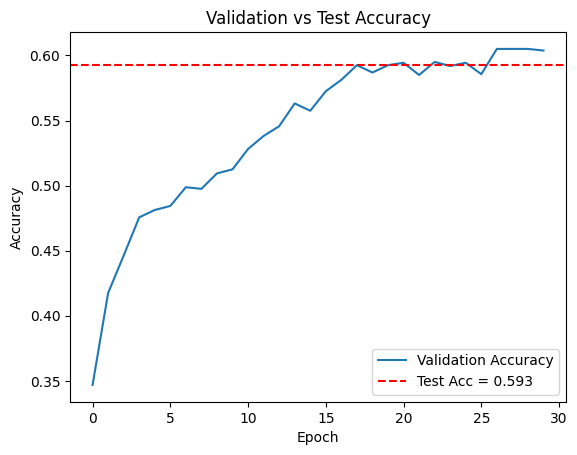

Final Test Accuracy: 0.5930


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,788 (952.30 KB)

 Trainable params: 243,786 (952.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [13]:
from tensorflow.keras import layers, models

model6 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    tf.keras.layers.Conv2D(64, 3, activation="relu"), # convelutional layer
    layers.MaxPool2D(),
    
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPool2D(),
    
    layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation="relu"), # dense layer
    layers.Dropout(0.5), #dropout is turining part of neurons while 
    # training to prevent overfitting.

    layers.Dense(10, activation='softmax')
])

model6.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.05),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model6.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val), verbose=1)
print()

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model6.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')

model6.summary()

I was not expecting such inpact out one Dropout it reduced fluctuations showing more steady growth in accuracy and validation training gap which indicates it is very much consistend. So far this is the best model in terms of accuracy and consistency.

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1217 - loss: 2.2931 - val_accuracy: 0.1562 - val_loss: 2.2763
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1441 - loss: 2.2682 - val_accuracy: 0.2200 - val_loss: 2.2114
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1939 - loss: 2.1937 - val_accuracy: 0.3556 - val_loss: 2.0740
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.2545 - loss: 2.1149 - val_accuracy: 0.3750 - val_loss: 1.9697
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2872 - loss: 2.0497 - val_accuracy: 0.3975 - val_loss: 1.8865
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.3175 - loss: 2.0069 - val_accuracy: 0.4244 - val_loss: 1.8369
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.3414 - loss: 1.9531 - val_accuracy: 0.4469 - val_loss: 1.7880
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3564 - loss: 1.9073 - val_accu

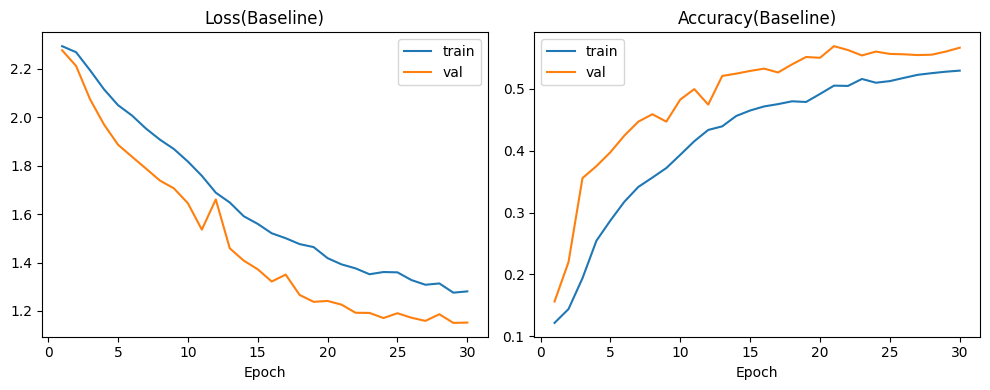

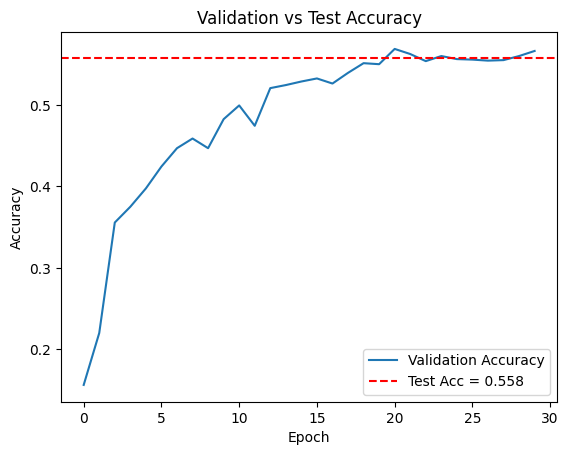

Final Test Accuracy: 0.5575


In [14]:
from tensorflow.keras import layers, models

model7 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu"), # convelutional layer
    layers.MaxPool2D(pool_size=2),
    
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    
    layers.Flatten(),
    
    tf.keras.layers.Dense(64, activation="relu"), # dense layer
    layers.Dropout(0.5), #dropout is turining part of neurons while 
    # training to prevent overfitting.
    tf.keras.layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

model7.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.05),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model7.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val), verbose=1)
print()

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model7.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')

I wanted to check how dividing one dense layer with 128 neurons with latter dropout 0.5 layer will behave if i split it in two sections like two 64 dense layeres and the resoult is drop in accuracy and bigger gap between validation and test.

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.2914 - loss: 2.0571 - val_accuracy: 0.4400 - val_loss: 1.7897
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4398 - loss: 1.7586 - val_accuracy: 0.4900 - val_loss: 1.5481
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4842 - loss: 1.5410 - val_accuracy: 0.5163 - val_loss: 1.3898
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5167 - loss: 1.4207 - val_accuracy: 0.5200 - val_loss: 1.3199
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5325 - loss: 1.3319 - val_accuracy: 0.5312 - val_loss: 1.2574
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5566 - loss: 1.2508 - val_accuracy: 0.5444 - val_loss: 1.2090
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5858 - loss: 1.1833 - val_accuracy: 0.5631 - val_loss: 1.1866
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6036 - loss: 1.1112 - val_accu

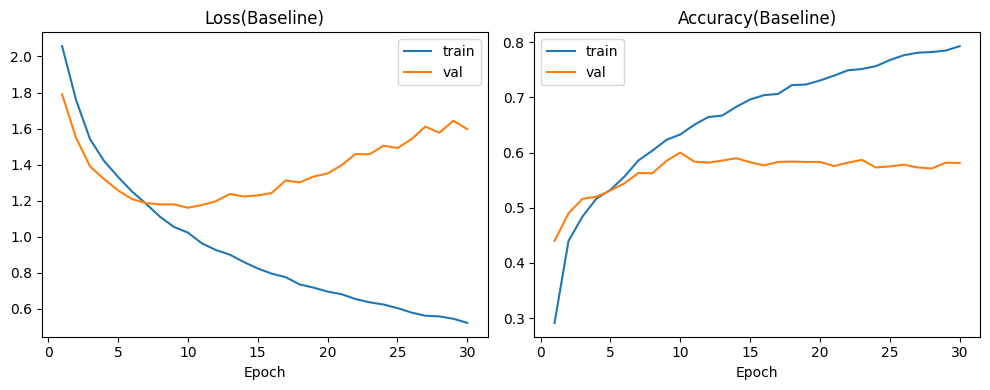

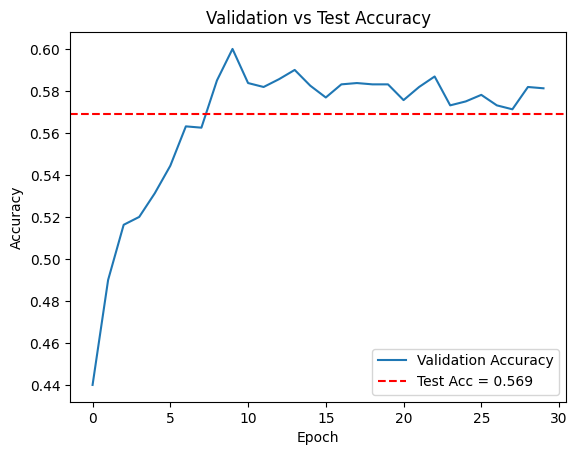

Final Test Accuracy: 0.5690


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,852 (30.68 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [15]:
from tensorflow.keras import layers, models

model8 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu"), # convelutional layer
    layers.MaxPool2D(pool_size=2),
    
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    
    layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation="relu"), # dense layer
    layers.Dropout(0.5), #dropout is turining part of neurons while 
    # training to prevent overfitting.

    layers.Dense(10, activation='softmax')
])

model8.compile(
    optimizer='adam', # switching to adam as more "adaptive" and faster the SGD
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model8.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val), verbose=1)
print()

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model8.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')

model.summary()


adam optimizer is in a sense acting faster then SGD but it makes it more unpredictable and less stable in this configuration there is no much use of it. I will try to use this to my advantage unpredictability in training can be solved by retriving the best outcome of the training and stabilizing the final outcome while reducing the required computing power. hopefully my theory will work.

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2348 - loss: 2.1455 - val_accuracy: 0.4462 - val_loss: 1.8659
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4031 - loss: 1.8748 - val_accuracy: 0.4812 - val_loss: 1.7069
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4505 - loss: 1.7150 - val_accuracy: 0.4913 - val_loss: 1.5635
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4852 - loss: 1.5583 - val_accuracy: 0.5088 - val_loss: 1.4360
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5016 - loss: 1.4613 - val_accuracy: 0.5200 - val_loss: 1.3454
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5230 - loss: 1.3872 - val_accuracy: 0.5206 - val_loss: 1.2997
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5402 - loss: 1.3191 - val_accuracy: 0.5400 - val_loss: 1.2607
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5575 - loss: 1.2580 - val_accuracy: 0.

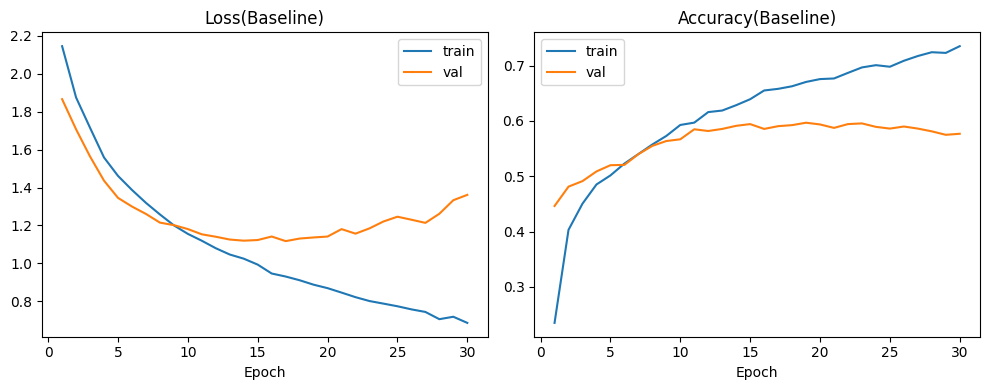

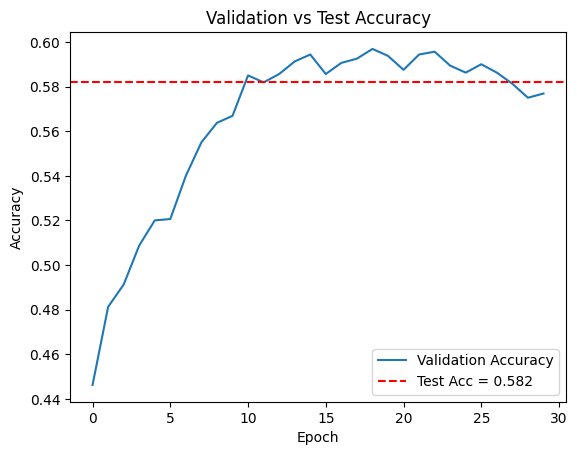

Final Test Accuracy: 0.5820


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 32)       │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 92)             │        47,196 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 92)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,124 (719.24 KB)

 Trainable params: 61,374 (239.74 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 122,750 (479.50 KB)

In [16]:
from tensorflow.keras import layers, models, callbacks

model9 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    tf.keras.layers.Conv2D(filters=16, kernel_size=5, activation="relu"), # convelutional layer
    layers.MaxPool2D(pool_size=2),
    
    tf.keras.layers.Conv2D(32, 5, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    
    layers.Flatten(),
    
    tf.keras.layers.Dense(92, activation="relu"), # dense layer
    layers.Dropout(0.5), #dropout is turining part of neurons while 
    # training to prevent overfitting.

    layers.Dense(10, activation='softmax')
])

model9.compile(
    optimizer='adam', # switching to adam as more "adaptive" and faster the SGD
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# this function stop the training when the validation loss stops improving 
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# callbacks.EarlyStopping creates callback that Keras will use during the training
# monitor='val_loss' it is saying that this function will evaluate the model by validation loss 
# patience=3 in this example if val_loss will not improve in 3 epochs it will trigger the function
# restore_best_weights=True after stopping the weights in model are restored from the best epoch

history = model9.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val), verbose=1)
print()

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model9.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')

model9.summary()


The resoult is very much a like to the previous one but i reduced number of filters and neurons in this model which makes it lighter by around 200KB in this context the remaining accuracy seems more as a success. The most important change in the code would be the early_stopping function that should reduce the use of resources and time as it should stop the training when the model is stopped impovment in terms of training validation relationship.

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2330 - loss: 2.1483 - val_accuracy: 0.4319 - val_loss: 1.8767
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3870 - loss: 1.9013 - val_accuracy: 0.4519 - val_loss: 1.7576
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4248 - loss: 1.7752 - val_accuracy: 0.4794 - val_loss: 1.6442
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4558 - loss: 1.6677 - val_accuracy: 0.4988 - val_loss: 1.5517
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4800 - loss: 1.5732 - val_accuracy: 0.5075 - val_loss: 1.4603
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4920 - loss: 1.5142 - val_accuracy: 0.5094 - val_loss: 1.4144
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4972 - loss: 1.4444 - val_accuracy: 0.5181 - val_loss: 1.3580
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5119 - loss: 1.3999 - val_accuracy: 0.

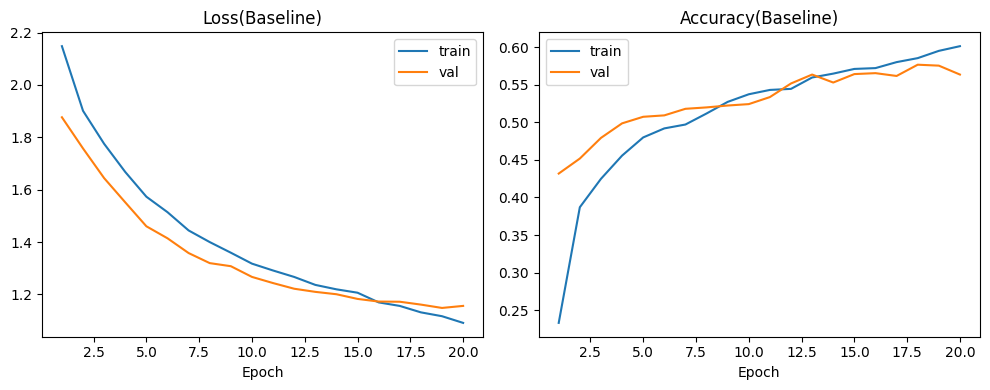

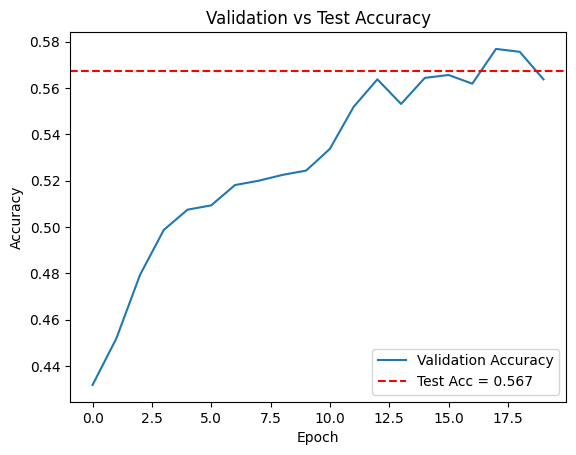

Final Test Accuracy: 0.5675


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 16)       │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 72)             │        18,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,976 (265.54 KB)

 Trainable params: 22,658 (88.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 45,318 (177.03 KB)

In [17]:
from tensorflow.keras import layers, models, callbacks

model10 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    tf.keras.layers.Conv2D(filters=8, kernel_size=5, activation="relu"), # convelutional layer
    layers.MaxPool2D(pool_size=2),
    
    tf.keras.layers.Conv2D(16, 5, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    
    layers.Flatten(),
    
    tf.keras.layers.Dense(72, activation="relu"), # dense layer
    layers.Dropout(0.5), #dropout is turining part of neurons while 
    # training to prevent overfitting.

    layers.Dense(10, activation='softmax')
])

model10.compile(
    optimizer='adam', # switching to adam as more "adaptive" and faster the SGD
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# this function stop the training when the validation loss stops improving 
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# callbacks.EarlyStopping creates callback that Keras will use during the training
# monitor='val_loss' it is saying that this function will evaluate the model by validation loss 
# patience=3 in this example if val_loss will not improve in 3 epochs it will trigger the function
# restore_best_weights=True after stopping the weights in model are restored from the best epoch

history = model10.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), verbose=1)
print()

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model10.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')

model10.summary()


I reduced number of neurons and filters and epochs and the model kept the accuracy on decent level with validation and training relationshipt intakt I will see how much i can push it

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6002 - loss: 1.0776 - val_accuracy: 0.5769 - val_loss: 1.1430
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6056 - loss: 1.0596 - val_accuracy: 0.5813 - val_loss: 1.1452
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6081 - loss: 1.0524 - val_accuracy: 0.5788 - val_loss: 1.1324
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6094 - loss: 1.0452 - val_accuracy: 0.5838 - val_loss: 1.1501
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6108 - loss: 1.0424 - val_accuracy: 0.5838 - val_loss: 1.1353
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6237 - loss: 1.0200 - val_accuracy: 0.5825 - val_loss: 1.1381
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6247 - loss: 1.0072 - val_accuracy: 0.5781 - val_loss: 1.1539
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6308 - loss: 0.9876 - val_accuracy: 0.

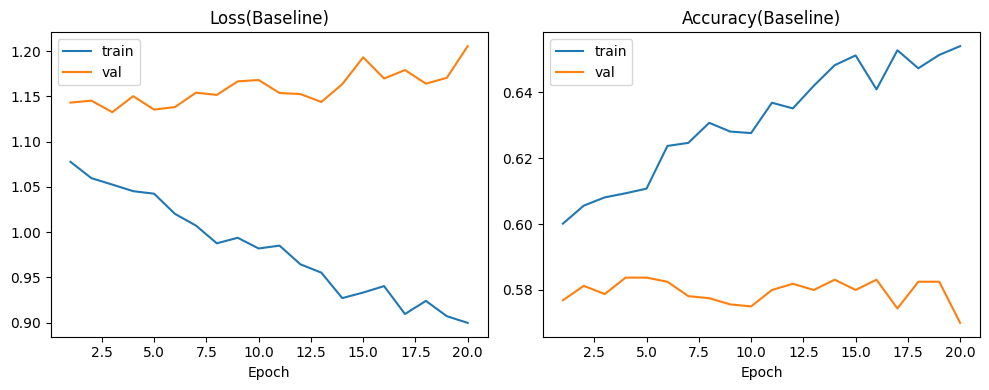

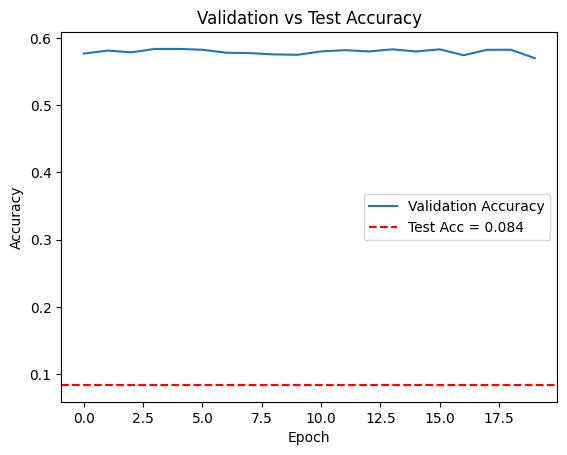

Final Test Accuracy: 0.0840


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 24, 24, 4)      │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 12, 12, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 8)        │           808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,370 (20.98 KB)

 Trainable params: 5,370 (20.98 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras import layers, models, callbacks

model11 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    tf.keras.layers.Conv2D(filters=4, kernel_size=5, activation="relu"), # convelutional layer
    layers.MaxPool2D(pool_size=2),
    
    tf.keras.layers.Conv2D(8, 5, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    
    layers.Flatten(),
    
    tf.keras.layers.Dense(32, activation="relu"), # dense layer
    layers.Dropout(0.5), #dropout is turining part of neurons while 
    # training to prevent overfitting.

    layers.Dense(10, activation='softmax')
])

model11.compile(
    optimizer='adam', # switching to adam as more "adaptive" and faster the SGD
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# this function stop the training when the validation loss stops improving 
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# callbacks.EarlyStopping creates callback that Keras will use during the training
# monitor='val_loss' it is saying that this function will evaluate the model by validation loss 
# patience=3 in this example if val_loss will not improve in 3 epochs it will trigger the function
# restore_best_weights=True after stopping the weights in model are restored from the best epoch

history = model10.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), verbose=1)
print()

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model11.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')

model11.summary()


This one is clearly too much now i need to meet in the middle and see when the model is returning satisfying resoults and uses the least resources

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1900 - loss: 2.2160 - val_accuracy: 0.3669 - val_loss: 2.0196
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3217 - loss: 2.0125 - val_accuracy: 0.4200 - val_loss: 1.8830
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3631 - loss: 1.9316 - val_accuracy: 0.4469 - val_loss: 1.8018
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3877 - loss: 1.8594 - val_accuracy: 0.4663 - val_loss: 1.7207
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4100 - loss: 1.7671 - val_accuracy: 0.4850 - val_loss: 1.6171
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4272 - loss: 1.6867 - val_accuracy: 0.4925 - val_loss: 1.5438
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4491 - loss: 1.6296 - val_accuracy: 0.4919 - val_loss: 1.4700
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4533 - loss: 1.5714 - val_accuracy: 0.

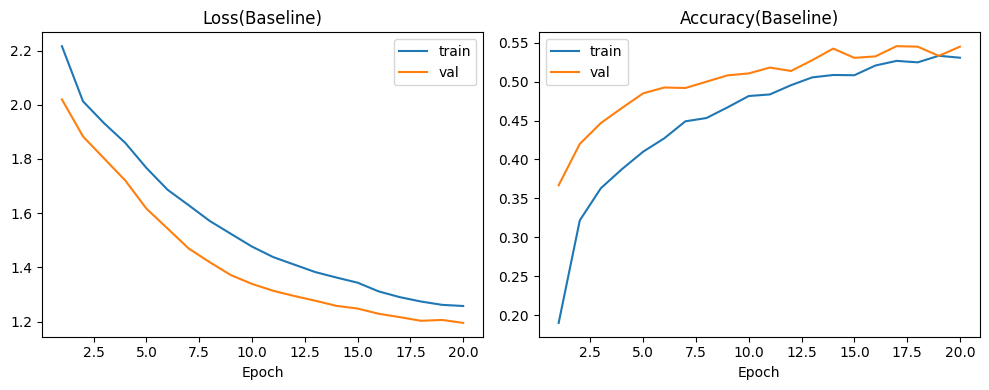

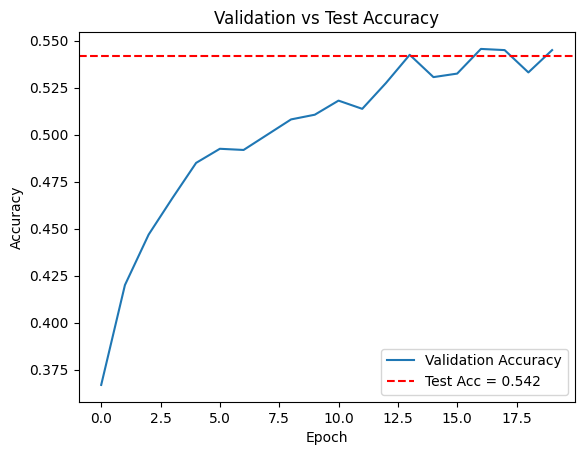

Final Test Accuracy: 0.5420


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 18)       │         3,618 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 18)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 48)             │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,566 (213.15 KB)

 Trainable params: 18,188 (71.05 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36,378 (142.11 KB)

Model saved at: /Users/beam/2026_spring/IoT_Pipline_2026/ML/JakubModel.keras


In [19]:
from tensorflow.keras import layers, models, callbacks

model12 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    tf.keras.layers.Conv2D(filters=8, kernel_size=5, activation="relu"), # convelutional layer
    layers.MaxPool2D(pool_size=2),
    
    tf.keras.layers.Conv2D(18, 5, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    
    layers.Flatten(),
    
    tf.keras.layers.Dense(48, activation="relu"), # dense layer
    layers.Dropout(0.5), #dropout is turining part of neurons while 
    # training to prevent overfitting.

    layers.Dense(10, activation='softmax')
])

model12.compile(
    optimizer='adam', # switching to adam as more "adaptive" and faster then SGD
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# this function stop the training when the validation loss stops improving 
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# callbacks.EarlyStopping creates callback that Keras will use during the training
# monitor='val_loss' it is saying that this function will evaluate the model by validation loss 
# patience=3 in this example if val_loss will not improve in 3 epochs it will trigger the function
# restore_best_weights=True after stopping the weights in model are restored from the best epoch

history = model12.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), verbose=1)
print()

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model12.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')

model12.summary()

path = "JakubModel.keras"

model12.save(path)

print("Model saved at:", os.path.abspath(path))


It seems as this model is captured in nearly perfect timing of optimal resoults without too extensive training with just right amount of computing power to do the job. It is not most accurate of the models but in terms of power consumption to output ratio it is clearly the best modol that I created here.

In [20]:
# Your work: replace with improved model
final_model = model12
final_history = history
print('Final model params:', final_model.count_params())


Final model params: 18188


In [21]:
from tensorflow import keras

loadedModel = keras.models.load_model("JakubModel.keras")

loss, acc = loadedModel.evaluate(X_all, y_all, verbose=1)
print(f"Loss={loss:.3f}, Acc={acc:.3f}")

prediction = loadedModel.predict(X_all, verbose=1)
predictionClasses = np.argmax(prediction, axis=1)

correct = np.sum(predictionClasses == y_all)
total = len(y_all)
print(f"Correct predictions: {correct} out of {total}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5801 - loss: 1.1229
Loss=1.123, Acc=0.580
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Correct predictions: 5801 out of 10000


In [25]:
def balanceCalculator(model):
    prediction = loadedModel.predict(X_test, verbose=0)
    predictionClasses = np.argmax(prediction, axis=1)

    params = model.count_params()
    correct = np.sum(predictionClasses == y_test)
    total = len(y_all)
    balance = 0

    print(f"Correct predictions: {correct} out of {total}")
    print(f"Params: {params}")
    print(25*"_")

    correct = int(correct)

    for i in range(correct):
        if i <= 5000:
            balance += 100
        elif i >= 5001 and i <= 6000:
            balance += 200
        else:
            balance += 1000

    balance = balance - params
        
    print(f"Balance: {balance}€")


balanceCalculator(loadedModel)

Correct predictions: 1084 out of 10000
Params: 18188
_________________________
Balance: 90212€
